# Lab 004 — Graph Execution Lifecycle

## Learning Objectives

By the end of this lab, you will:

- Understand how a LangGraph workflow executes
- Learn the lifecycle of a graph invocation
- Observe how state changes as nodes execute
- Use streaming to inspect execution step-by-step

---

## Concept Overview

When a graph is executed, LangGraph follows a predictable lifecycle.

```text
Input State
     |
     v
START
     |
     v
Node Execution
     |
     v
State Updates
     |
     v
END
     |
     v
Final State
```

At each step:

1. The current state is passed to a node.
2. The node performs work.
3. The node returns state updates.
4. LangGraph merges the updates into the current state.
5. Execution moves to the next node.

---

## Workflow Diagram

```text
START
   |
node_a
   |
node_b
   |
  END
```

---

## Step 1 — Imports


In [4]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph import START, END

---

## Step 2 — Define State


In [5]:
class State(TypedDict):
    message: str


---

## Step 3 — Create the Nodes

### Node A


In [6]:
def node_a(state: State):
    print("Executing node_a")

    return {
        "message": state["message"] + " A"
    }


### Node B


In [7]:
def node_b(state: State):
    print("Executing node_b")

    return {
        "message": state["message"] + " B"
    }

---

## Step 4 — Build the Graph


In [8]:
builder = StateGraph(State)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)


---

## Step 5 — Compile the Graph


In [9]:
graph = builder.compile()

---

## Step 6 — Execute the Graph


Console output:

```text
Executing node_a
Executing node_b
```


Final state:

```python
{
    "message": "Start A B"
}
```


In [10]:
result = graph.invoke(
    {
        "message": "Start"
    }
)

Executing node_a
Executing node_b


---

## Understanding What Happened

### Initial State

```python
{
    "message": "Start"
}
```

---

### Execution Begins

LangGraph starts at:

```text
START
```

---

### Execute node_a

Input:

```python
{
    "message": "Start"
}
```

Output:

```python
{
    "message": "Start A"
}
```

Updated state:

```python
{
    "message": "Start A"
}
```

---

### Execute node_b

Input:

```python
{
    "message": "Start A"
}
```

Output:

```python
{
    "message": "Start A B"
}
```

Updated state:

```python
{
    "message": "Start A B"
}
```

---

### Reach END

Execution terminates.

Final state:

```python
{
    "message": "Start A B"
}
```

---

## Streaming Execution

Instead of waiting for the final result, we can watch the graph execute step-by-step.

Example output:

```python
{
    "node_a": {
        "message": "Start A"
    }
}

{
    "node_b": {
        "message": "Start A B"
    }
}
```


In [15]:
for event in graph.stream(
    {
        "message": "Start"
    }
):
    print(event)

Executing node_a
{'node_a': {'message': 'Start A'}}
Executing node_b
{'node_b': {'message': 'Start A B'}}


Streaming is useful for:

- Debugging
- Monitoring execution
- Understanding workflow behavior

---

## Visualize the Workflow


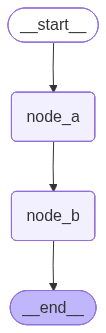

In [16]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


Expected structure:

```text
START
   |
node_a
   |
node_b
   |
  END
```

---

## Key Takeaways

- Graph execution always starts at `START`.
- Nodes execute according to graph topology.
- Each node receives the current state.
- Nodes return state updates.
- LangGraph updates the state after every node execution.
- Execution ends when the workflow reaches `END`.
- Streaming allows you to observe execution as it happens.